In [14]:
import pandas as pd

# Load data
df = pd.read_csv("D:\\New folder\\Cars_data (1).csv")

# Clean numeric columns with commas and strings at the end (e.g., "10,000 km", "15.5 L", "100 bhp")
numeric_cols = ["price", "km_driven", "mileage_new", "max_engine_capacity_new"]
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)  # Ensure all values are strings
        .str.replace(",", "", regex=False)  # Remove commas
        .str.extract(r"([0-9.]+)")  # Extract numeric part using regex
        .squeeze()  # Convert DataFrame to Series if needed
        .astype(float)  # Convert to float
    )

# Verify the cleaned columns
print(df[numeric_cols].head())


      price  km_driven  mileage_new  max_engine_capacity_new
0  950000.0   150000.0        12.99                   2494.0
1  500000.0    53755.0        15.10                   2179.0
2  738000.0    53838.0        18.53                   1199.0
3  850000.0    28112.0        15.80                   1591.0
4  899999.0    63125.0        24.52                   1248.0


In [15]:
# Example: "100.6bhp@3600rpm" → 100.6
df["max_power"] = df["Max Power"].str.extract(r"(\d+\.\d+|\d+)").astype(float)
df["max_torque"] = df["Max Torque"].str.extract(r"(\d+\.\d+|\d+)").astype(float)


In [16]:
# Drop rows with missing price
df.dropna(subset=["price"], inplace=True)

# Fill missing values
df["mileage_new"].fillna(df["mileage_new"].median())

0        12.99
1        15.10
2        18.53
3        15.80
4        24.52
         ...  
34028    17.42
34029    27.39
34030    18.60
34031    18.60
34032    21.21
Name: mileage_new, Length: 34033, dtype: float64

In [17]:
df["max_power"].fillna(df["max_power"].median())
df["max_torque"].fillna(df["max_torque"].median())

0        200.0
1        330.0
2        113.0
3        151.0
4        200.0
         ...  
34028    320.0
34029    190.0
34030    114.7
34031    114.7
34032    113.0
Name: max_torque, Length: 34033, dtype: float64

In [18]:
# Remove rows where 'max_engine_capacity_new' is equal to 0
df = df[df['max_engine_capacity_new'] != 0]

In [19]:
import numpy as np

# Define columns to check for outliers
log_cols = ['max_power', 'max_torque', 'max_engine_capacity_new', 'price']

# For each column, remove rows where the value is outside 1.5*IQR from Q1 or Q3
for col in log_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [20]:
import numpy as np

df["log_max_power"] = np.log(df["max_power"])
df["log_max_torque"] = np.log(df["max_torque"])
df["log_max_engine_capacity_new"] = np.log(df["max_engine_capacity_new"])
df["log_km_driven"] = np.log(df["km_driven"])


In [21]:
import numpy as np

features = [
    
 "log_km_driven", "mileage_new", 
    "log_max_power", "log_max_torque",
 "log_max_engine_capacity_new"

]

df = df.dropna(subset=["price"])
df = df.dropna(subset=features)
X = df[features]
#y = df["price"]
y = np.log(df["price"])  # Natural logarithm (base e)

In [22]:
# Identify negative values in 'max_engine_capacity_new'
neg_values = df[df['max_engine_capacity_new'] < 0]
print("Rows with negative 'max_engine_capacity_new':")
print(neg_values[['max_engine_capacity_new']])
print(f"Total negative values: {len(neg_values)}")

Rows with negative 'max_engine_capacity_new':
Empty DataFrame
Columns: [max_engine_capacity_new]
Index: []
Total negative values: 0


In [23]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


X_train, X_val = train_test_split(X,test_size=0.2,random_state=44,shuffle=True)
y_train, y_val = train_test_split(y,test_size=0.2,random_state=44,shuffle=True)



scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


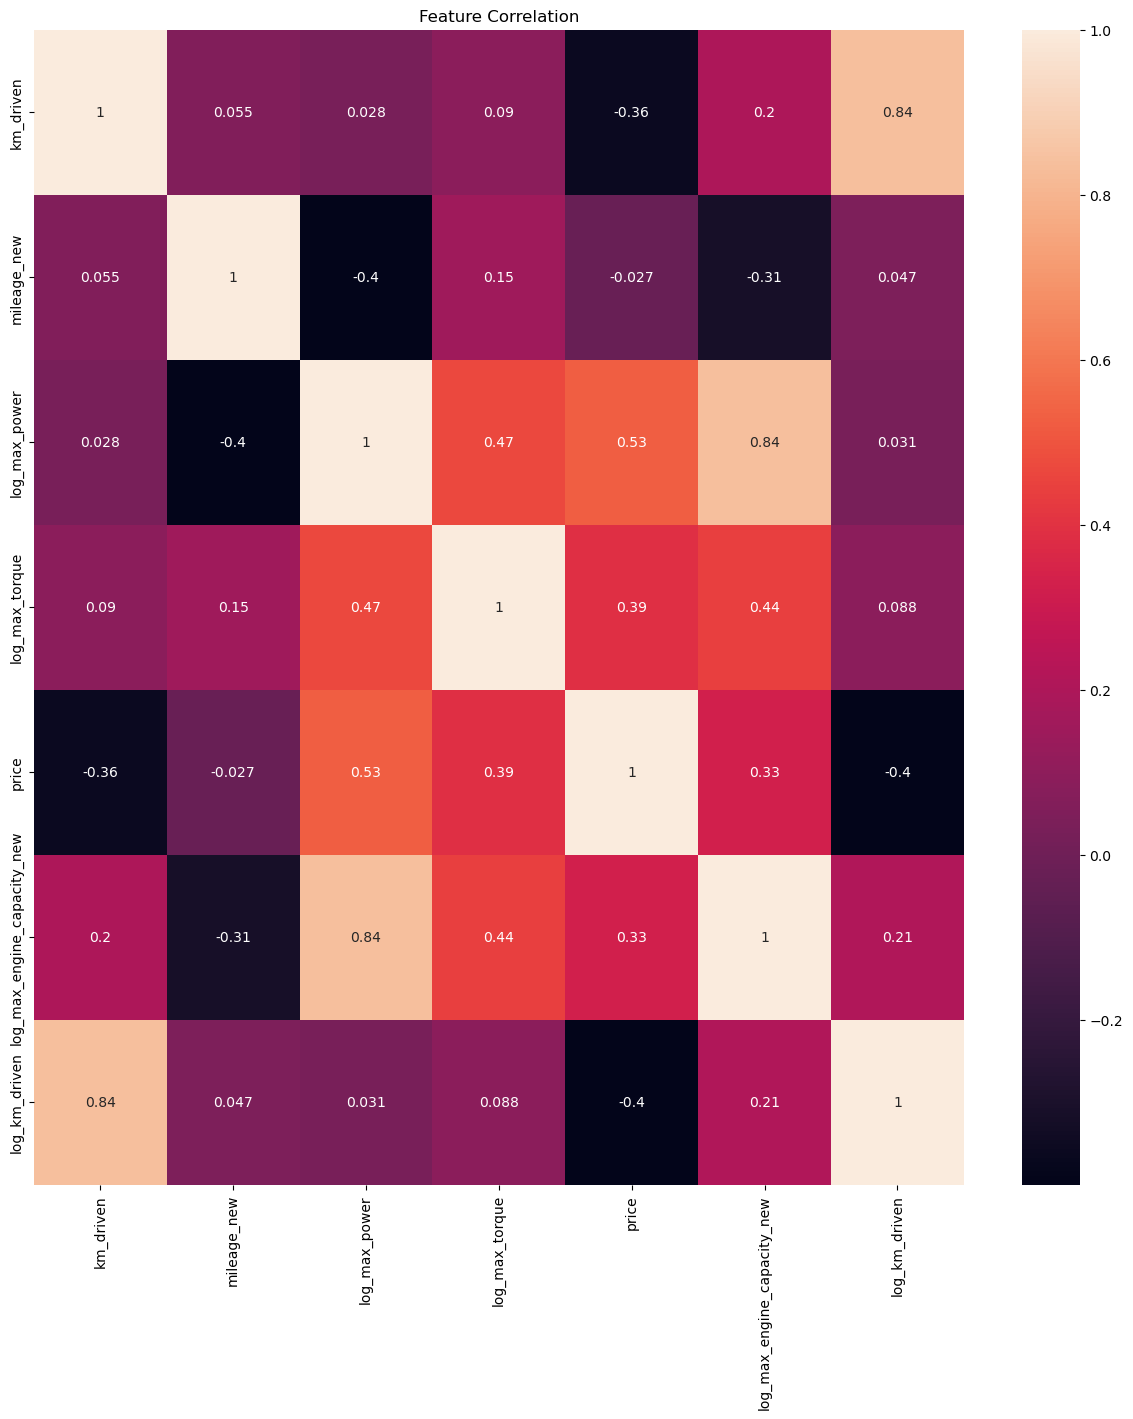

In [24]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

plt.figure(figsize=(15, 15))

sns.heatmap(df[[
"km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
 "log_max_engine_capacity_new", "log_km_driven"
]].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

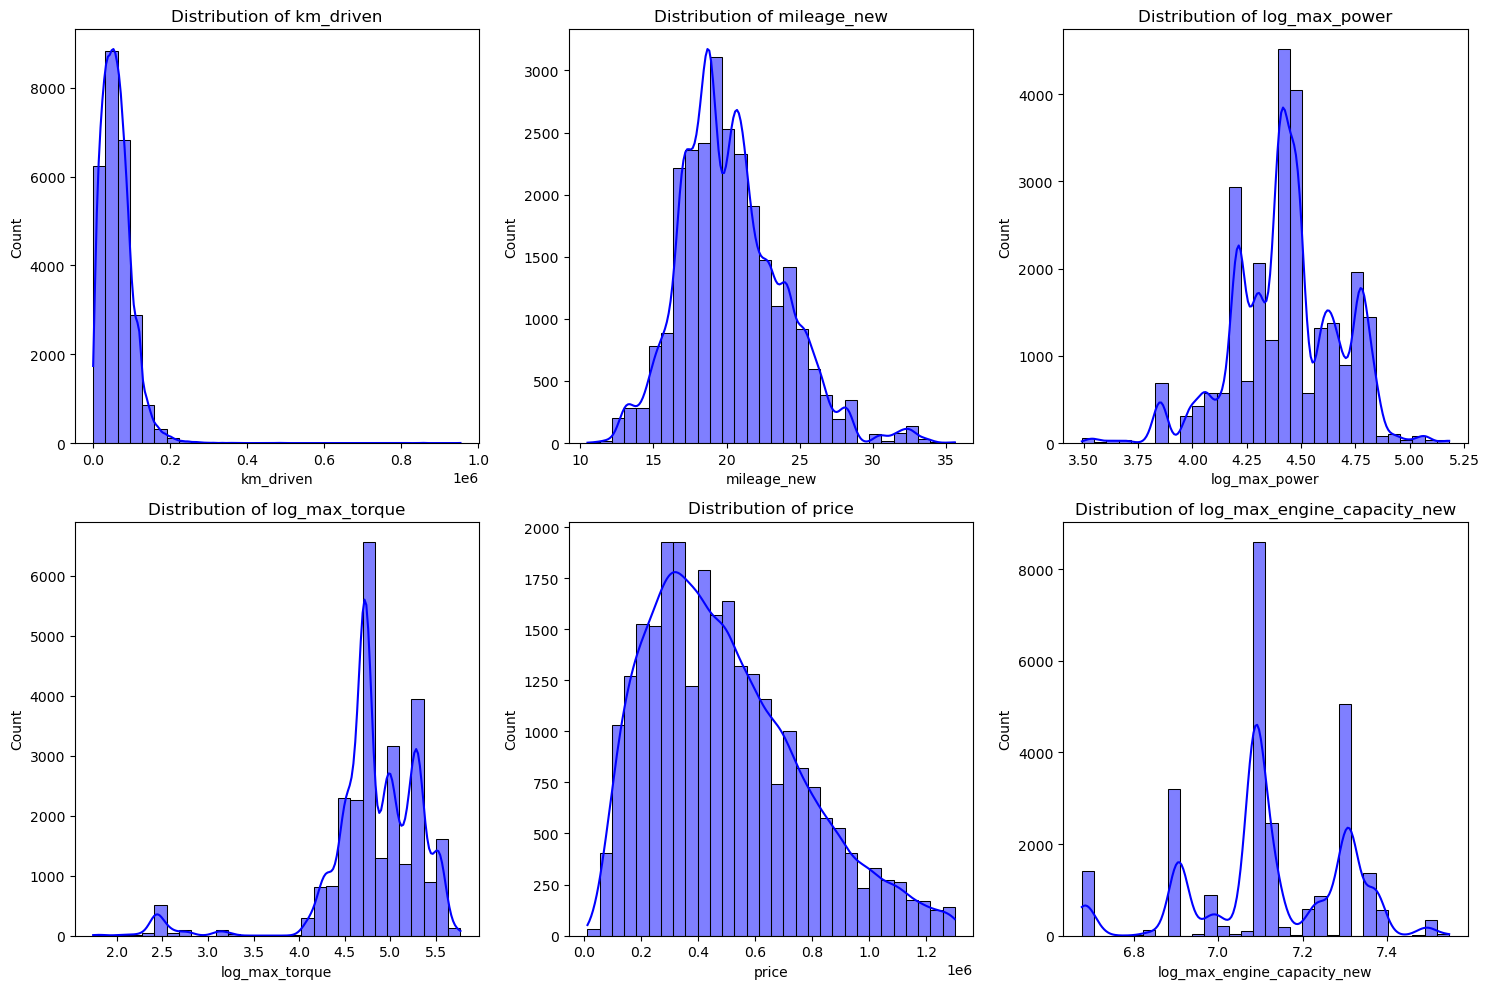

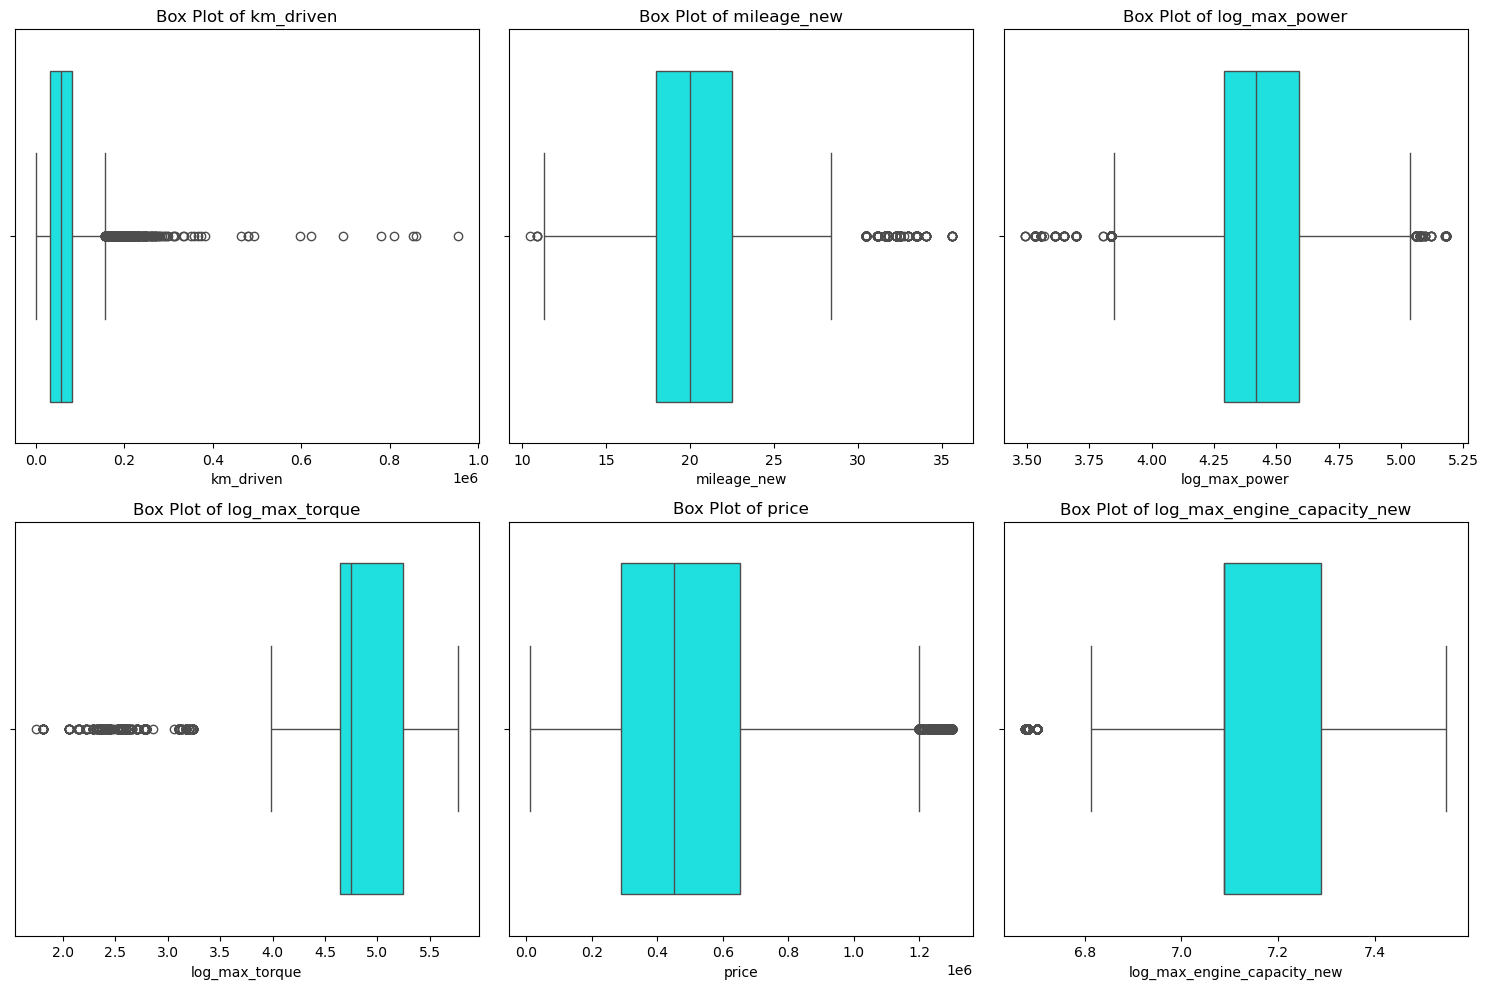

In [25]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "log_max_power", "log_max_torque", "price",
    "log_max_engine_capacity_new"
]

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

Testing model with 2 hidden layers and 64 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 2, Neurons: 64, Train MSE: 0.16, Val MSE: 0.18
Testing model with 2 hidden layers and 128 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 2, Neurons: 128, Train MSE: 0.16, Val MSE: 0.28
Testing model with 2 hidden layers and 180 neurons


...

Layers: 6, Neurons: 128, Train MSE: 0.18, Val MSE: 0.16
Testing model with 6 hidden layers and 180 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 6, Neurons: 180, Train MSE: 0.19, Val MSE: 0.22
Testing model with 6 hidden layers and 256 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 6, Neurons: 256, Train MSE: 0.19, Val MSE: 0.16


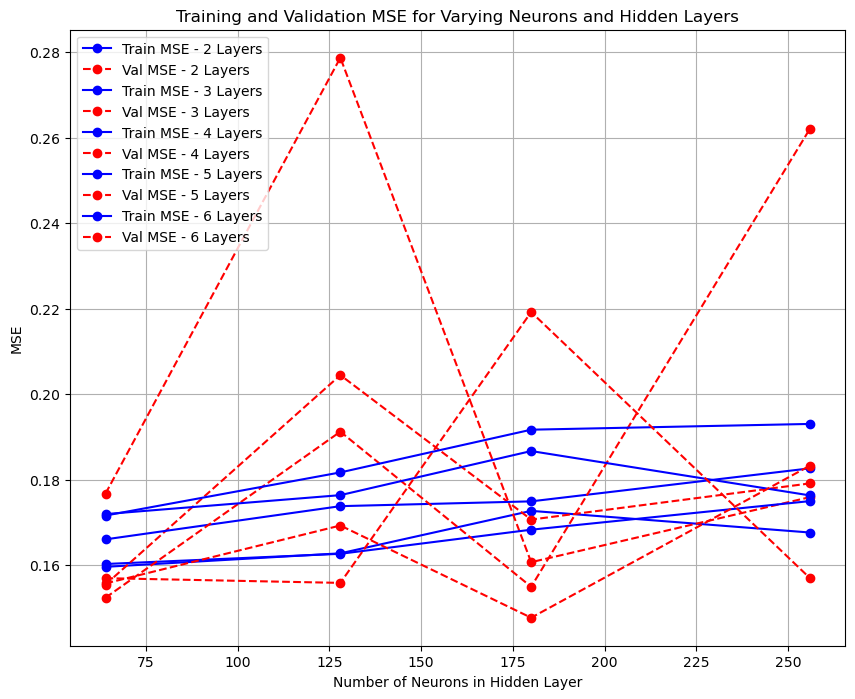

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define neuron configurations (4 different numbers of neurons)
neuron_no = [ 16, 32, 64 ]  # Neurons
layer_no = [ 2, 3, 4  ]  # Number of hidden layers

mse_train = {layers: [] for layers in layer_no}  # Store training MSE for each layer configuration
mse_val = {layers: [] for layers in layer_no}  # Store validation MSE for each layer configuration

# Loop over different numbers of hidden layers (1, 2, 3, 4 layers)
for layers in layer_no:
    for neurons in neuron_no:
        print(f"Testing model with {layers} hidden layers and {neurons} neurons")
        
        # Build the model with the specified number of hidden layers and neurons
        model = Sequential()
        model.add(Dense(neurons, activation='relu', input_shape=(X_train.shape[1],)))  # Input + 1st hidden layer
        for _ in range(layers - 1):  # Add additional hidden layers
            model.add(Dense(neurons, activation='relu'))
        model.add(Dense(1))  # Output layer for regression
        
        # Compile and train the model
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=0)

        # Store the MSE for both training and validation
        mse_train[layers].append(history.history['loss'][-1])  # Last epoch training MSE
        mse_val[layers].append(history.history['val_loss'][-1])  # Last epoch validation MSE
        print(f"Layers: {layers}, Neurons: {neurons}, Train MSE: {mse_train[layers][-1]:.2f}, Val MSE: {mse_val[layers][-1]:.2f}")

# Plot MSE for both training and validation for each configuration
plt.figure(figsize=(10, 8))

# Plot for each layer configuration
for layers in layer_no:
    plt.plot(neuron_no, mse_train[layers], marker='o', label=f'Train MSE - {layers} Layers', linestyle='-', color='blue')
    plt.plot(neuron_no, mse_val[layers], marker='o', label=f'Val MSE - {layers} Layers', linestyle='--', color='red')

plt.title("Training and Validation MSE for Varying Neurons and Hidden Layers")
plt.xlabel("Number of Neurons in Hidden Layer")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_100 (Dense)               │ (None, 256)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,913 (777.00 KB)

 Trainable params: 198,913 (777.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 8.6598 - mae: 1.8272 - val_loss: 0.3422 - val_mae: 0.4666
Epoch 2/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 1.9104 - mae: 1.1109 - val_loss: 0.7300 - val_mae: 0.7515
Epoch 3/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.6330 - mae: 1.0262 - val_loss: 0.7452 - val_mae: 0.7771
Epoch 4/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 1.3079 - mae: 0.9164 - val_loss: 0.4896 - val_mae: 0.5845
Epoch 5/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.0550 - mae: 0.8206 - val_loss: 0.7263 - val_mae: 0.7667
Epoch 6/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.9781 - mae: 0.7905 - val_loss: 0.2776 - val_mae: 0.4012
Epoch 7/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.9570 - mae: 0.7805 - val_loss: 1.0007 - val_mae: 0.9155
Epoch 8/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9310 - mae: 0.7702 - val_loss: 0.2038 - val_mae: 0.3772
Epoch 9/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 

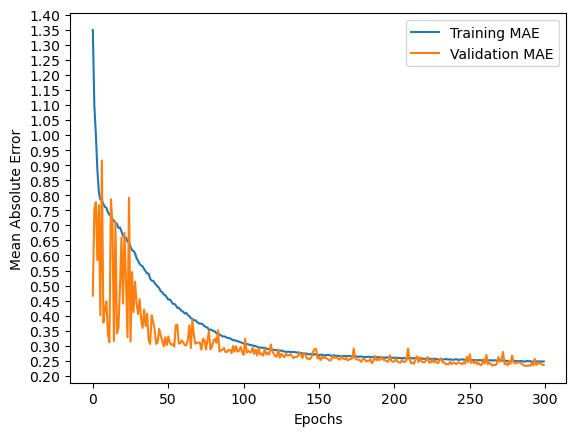

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model10 = Sequential([
    Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(512, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model10.summary()
model10.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model10.fit(X_train, y_train, epochs=300,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


In [28]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict on validation or test set
y_pred_log = model10.predict(X_val).flatten()  # predictions in log scale
y_true_log = y_val  # true values in log scale

# Convert back to original scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_true_log)

# Calculate MAE in original price units
mae_real = mean_absolute_error(y_true, y_pred)
print("MAE in original price units:", mae_real)

164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE in original price units: 102557.56393513203


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model5 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(1)
])
model5.summary()
model5.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

In [ ]:

history = model5.fit(X_train, y_train, epochs=300,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()